In [3]:
import xsimlab as xs
import numpy as np
from datetime import datetime
from vmlab.processes.arch_dev_veg_within import ArchDevVegWithin # Importamos la clase base
from vmlab.processes._base.probability_table import ProbabilityTableProcess
from vmlab.processes._base.parameter import ParameterizedProcess

@xs.process
class QuercusArchDev(ArchDevVegWithin):
    """
    Proceso de arquitectura personalizado para Quercus.
    Sobrescribe la lógica estadística del mango con reglas deterministas
    simples basadas en inferencias paleobotánicas.
    """

    def initialize(self):
        # 1. Llamamos al inicializador del ABUELO (ParameterizedProcess)
        #    para cargar el archivo de parámetros .toml
        super(ProbabilityTableProcess, self).initialize() 
        
        # 2. Llamamos al inicializador del PADRE (ProbabilityTableProcess)
        #    para configurar el generador de números aleatorios (self.rng)
        super(ArchDevVegWithin, self).initialize()
        
        # 3. Copiamos la inicialización de variables de ArchDevVegWithin
        #    (la parte que SÍ queremos para pre-llenar los arrays)
        self.has_veg_children_within = np.zeros(self.GU.shape, dtype=np.float32)
        self.has_apical_child_within = np.zeros(self.GU.shape, dtype=np.float32)
        self.burst_date_children_within = np.full(self.GU.shape, np.datetime64('NaT'), dtype='datetime64[D]')
        self.burst_month_children_within = np.where(
            self.burst_date_children_within != np.datetime64('NaT'),
            self.burst_date_children_within.astype('datetime64[M]').astype(np.int) % 12 + 1,
            -1
        ).astype(np.int8)
        self.has_lateral_children_within = np.zeros(self.GU.shape, dtype=np.float32)
        self.nb_lateral_children_within = np.zeros(self.GU.shape, dtype=np.float32)
        
        # 4. OMITIMOS la parte que no queremos:
        # probability_tables = self.get_probability_tables()
        # self.tbls_... = ...
        print("🌳 QuercusArchDev inicializado: Tablas de probabilidad del Mango IGNORADAS.")

        # 5. Ejecutamos el run_step inicial (copiado de ArchDevVegWithin)
        #    (Esto es necesario para configurar el estado inicial del árbol)
        self.run_step(-1, self.sim_start_date)


    @xs.runtime(args=('step', 'step_start'))
    def run_step(self, step, step_start):
        """
        Sobrescribe el run_step() del mango.
        En lugar de muestrear de tablas, aplicamos reglas simples.
        """
        
        # 1. Determinar qué GUs están activas (copiado del original)
        appeared = (self.appeared == 1.) if step >= 0 else (self.is_initially_terminal == 1.)
        
        if not np.any(appeared):
            return # No hay nada que hacer

        # --- 2. NUEVA LÓGICA DE REGLAS DE QUERCUS ---
        
        # REGLA 1 (Hipótesis): Todas las yemas que brotan tienen potencial de crecimiento.
        self.has_veg_children_within[appeared] = 1.0

        # REGLA 2 (Hipótesis): Dominancia Apical Fuerte (típico de Quercus)
        # Las yemas apicales (is_apical == 1) SIEMPRE crean un hijo apical.
        is_apical_and_appeared = appeared & (self.is_apical == 1.)
        is_lateral_and_appeared = appeared & (self.is_apical == 0.)
        
        self.has_apical_child_within[is_apical_and_appeared] = 1.0
        
        # REGLA 3 (Hipótesis): Ramas Laterales (fijas)
        self.has_lateral_children_within[appeared] = 1.0 
        self.nb_lateral_children_within[is_apical_and_appeared] = 2 # 2 ramas en yemas apicales
        self.nb_lateral_children_within[is_lateral_and_appeared] = 1 # 1 rama en yemas laterales

        # REGLA 4 (Hipótesis): Fecha de Brotación Simplificada
        # Todas brotan el primer día del mes siguiente.
        next_month_date = step_start.astype('datetime64[M]') + np.timedelta64(1, 'M')
        self.burst_date_children_within[appeared] = next_month_date
        
        # --- 3. FIN ---
        # No hay ninguna llamada a .get_binomial() o .get_poisson().
        # Has reemplazado exitosamente la lógica del mango.

--- Modelo vQuercus Híbrido Creado ---
Ejecutando simulación de arquitectura Quercus...


             0% | initialize 

C:\Users\jcarlos.vargas\AppData\Local\Temp\ipykernel_12412\2975420377.py:32: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self.burst_date_children_within.astype('datetime64[M]').astype(np.int) % 12 + 1,


🌳 QuercusArchDev inicializado: Tablas de probabilidad del Mango IGNORADAS.


c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\xarray\core\utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


Simulación completada.


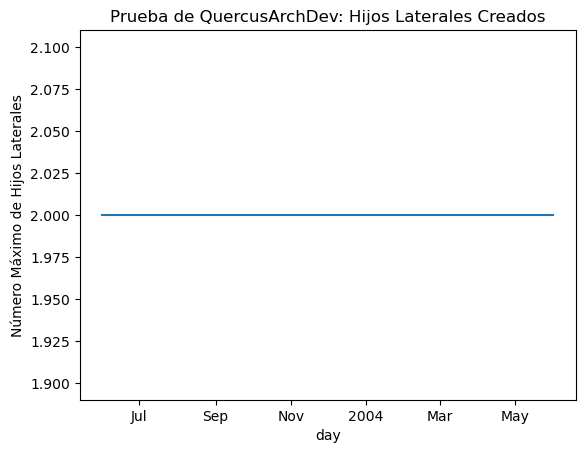

In [7]:
from vmlab.models import vmango
import vmlab.processes.phenology as phenology
import vmlab.processes.environment as environment
from vmlab.processes.harvest import Harvest
from importlib import resources
import vmlab
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Crear el modelo vquercus HÍBRIDO ---
vquercus_model = vmango.update_processes({
    # Reemplaza el proceso del mango por el nuestro
    'arch_dev_veg_within': QuercusArchDev 
})

# Eliminar procesos que no necesitamos para esta prueba funcional
vquercus_model = vquercus_model.drop_processes('geometry')
# vquercus_model = vquercus_model.drop_processes('appearance')

print("--- Modelo vQuercus Híbrido Creado ---")

# --- 2. Cargar el árbol inicial ---
with resources.path('vmlab.data.trees', 'tree_B10_cycle_030405.csv') as path:
    initial_tree = pd.read_csv(path)

# --- 3. Configurar la simulación ---
setup = vmlab.create_setup(
    model=vquercus_model, 
    tree=initial_tree,
    start_date='2003-06-01',
    end_date='2004-06-01', 
    setup_toml='vmango_fosil.toml', # Su paleoclima
    input_vars={},
    output_vars={
        'topology': {'appeared': 'day'},
        'arch_dev_veg_within': {
            # Pedimos la variable que manipulamos para verificar
            'nb_lateral_children_within': 'day' 
        }
    }
)

# --- 4. Ejecutar ---
print("Ejecutando simulación de arquitectura Quercus...")
ds_out = vmlab.run(setup, vquercus_model, geometry=False)
print("Simulación completada.")

# --- 5. Verificar ---
# Grafiquemos el número máximo de hijos laterales creados cada día
# Si no es 0, ¡nuestra regla funcionó!
ds_out.arch_dev_veg_within__nb_lateral_children_within.max(dim='GU').plot()
plt.title("Prueba de QuercusArchDev: Hijos Laterales Creados")
plt.ylabel("Número Máximo de Hijos Laterales")
plt.show()